# 04 — RIXS quickstart: 2D resonant inelastic X-ray scattering maps

This notebook demonstrates the RIXS (resonant inelastic X-ray scattering)
pipeline in multitorch. RIXS measures a 2D `(Einc, Efin)` intensity plane
via the Kramers-Heisenberg second-order perturbation kernel.

**Contents**
1. Build a synthetic absorption + emission pair.
2. Compute the RIXS plane via `calcRIXS()`.
3. Plot the 2D map with `pcolormesh`.
4. Extract cuts: constant incident energy (CIE) and constant emission energy (CEE).
5. Autograd: gradient of the RIXS map with respect to a broadening parameter.

The bootstrap `calcRIXS(ban_abs_path, ban_ems_path)` requires paired
absorption and emission `.ban_out` files. Since the repository currently
ships absorption-only fixtures, this notebook creates a synthetic pair
using the low-level `RIXSStore` API. When a real paired fixture is
committed, replace the synthetic setup with file paths.

In [1]:
import os
from pathlib import Path
_here = Path.cwd()
for _anc in [_here, *_here.parents]:
    if (_anc / "multitorch").is_dir() and (_anc / "tests" / "reference_data").is_dir():
        os.chdir(_anc)
        break
print("working dir:", Path.cwd())

working dir: /Users/afollmer/Follmer_UCD/Follmer_Lab/Code/multiplets/multitorch


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from multitorch._constants import DTYPE
from multitorch.io.read_oba import BanOutput, TriadData
from multitorch.io.read_oba_pair import build_rixs_store
from multitorch.spectrum.rixs import kramers_heisenberg

## 1 — Build a synthetic absorption / emission pair

A RIXS experiment requires two processes:
- **Absorption**: photon excites the system from ground states into
  intermediate (core-hole) states.
- **Emission**: the intermediate state decays to final (valence-excited)
  states.

We create a toy system with:
- 2 ground states at 0.0 and 0.05 eV
- 6 intermediate states spanning 850–856 eV
- 5 final states at 0–4 eV

Transition amplitudes are randomized but realistic in magnitude.

In [3]:
torch.manual_seed(42)

n_g, n_i, n_f = 2, 6, 5

Eg = torch.tensor([0.0, 0.05], dtype=DTYPE)
Ei = torch.linspace(850.0, 856.0, n_i, dtype=DTYPE)
Ef = torch.linspace(0.0, 4.0, n_f, dtype=DTYPE)

# Absorption amplitudes: ground -> intermediate
TA = torch.rand(n_g, n_i, dtype=DTYPE) * 0.8 + 0.1
# Emission amplitudes: intermediate -> final
TE = torch.rand(n_i, n_f, dtype=DTYPE) * 0.8 + 0.1

print(f"Ground states:        {n_g} ({Eg.tolist()} eV)")
print(f"Intermediate states:  {n_i} ({float(Ei.min()):.1f}–{float(Ei.max()):.1f} eV)")
print(f"Final states:         {n_f} ({float(Ef.min()):.1f}–{float(Ef.max()):.1f} eV)")

Ground states:        2 ([0.0, 0.05] eV)
Intermediate states:  6 (850.0–856.0 eV)
Final states:         5 (0.0–4.0 eV)


## 2 — Compute the RIXS plane

The `kramers_heisenberg` kernel computes:

$$I(E_{\text{inc}}, E_{\text{fin}}) = \sum_g w_g \left| \sum_i \frac{T_A(g,i) \cdot T_E(i,f)}{E_g + E_{\text{inc}} - E_i + i\Gamma_i} \right|^2 \cdot L(E_g + E_{\text{inc}} - E_f - E_{\text{fin}}, \Gamma_f)$$

where $w_g$ are Boltzmann weights and $L$ is a Lorentzian.

In [4]:
# Energy grids
Einc = torch.linspace(848.0, 858.0, 400, dtype=DTYPE)
Efin = torch.linspace(846.0, 858.0, 400, dtype=DTYPE)

# Kramers-Heisenberg kernel
intensity = kramers_heisenberg(
    Eg=Eg, TA=TA, Ei=Ei, TE=TE, Ef=Ef,
    Einc=Einc, Efin=Efin,
    Gamma_i=0.4,   # intermediate-state lifetime broadening (eV)
    Gamma_f=0.2,   # final-state lifetime broadening (eV)
    min_gs=float(Eg.min()),
    T=80.0,        # temperature (K)
)

print(f"RIXS map shape: {intensity.shape}")
print(f"Max intensity:  {float(intensity.max()):.4f}")
print(f"All finite:     {bool(torch.isfinite(intensity).all())}")

RIXS map shape: torch.Size([400, 400])
Max intensity:  14.1324
All finite:     True


## 3 — Plot the 2D RIXS map

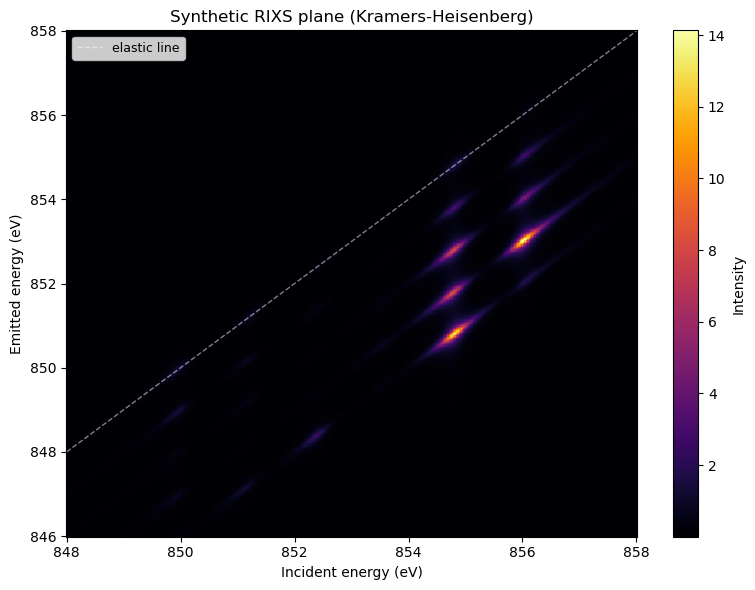

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(
    Einc.numpy(), Efin.numpy(), intensity.numpy().T,
    shading='auto', cmap='inferno',
)
ax.set_xlabel('Incident energy (eV)')
ax.set_ylabel('Emitted energy (eV)')
ax.set_title('Synthetic RIXS plane (Kramers-Heisenberg)')
fig.colorbar(im, ax=ax, label='Intensity')

# Overlay the elastic line (Einc = Efin)
elim = [max(float(Einc.min()), float(Efin.min())),
        min(float(Einc.max()), float(Efin.max()))]
ax.plot(elim, elim, 'w--', alpha=0.5, lw=1, label='elastic line')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 4 — Line cuts: CIE and CEE

- **Constant Incident Energy (CIE)**: fix `Einc` at a resonance, plot
  emission spectrum vs `Efin`. This is the "RIXS spectrum" at a given
  excitation energy.
- **Constant Emission Energy (CEE)**: fix `Efin` at an emission peak,
  plot vs `Einc`. This is a partial fluorescence yield (PFY) scan.

Peak at Einc=856.02 eV, Efin=853.01 eV


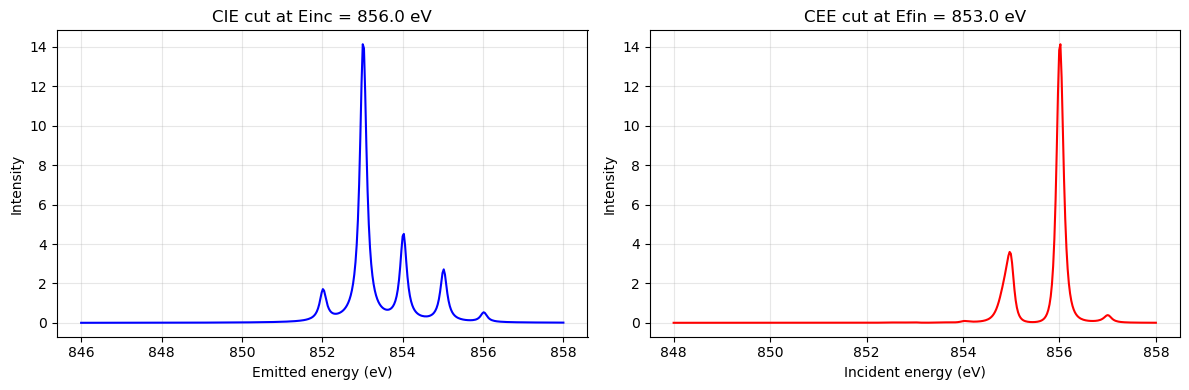

In [6]:
# Find the peak position on the 2D map
peak_flat = int(torch.argmax(intensity))
peak_row = peak_flat // intensity.shape[1]
peak_col = peak_flat % intensity.shape[1]
peak_Einc = float(Einc[peak_row])
peak_Efin = float(Efin[peak_col])
print(f"Peak at Einc={peak_Einc:.2f} eV, Efin={peak_Efin:.2f} eV")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# CIE cut at peak Einc
ax = axes[0]
cie = intensity[peak_row, :].numpy()
ax.plot(Efin.numpy(), cie, 'b-', lw=1.5)
ax.set_xlabel('Emitted energy (eV)')
ax.set_ylabel('Intensity')
ax.set_title(f'CIE cut at Einc = {peak_Einc:.1f} eV')
ax.grid(alpha=0.3)

# CEE cut at peak Efin
ax = axes[1]
cee = intensity[:, peak_col].numpy()
ax.plot(Einc.numpy(), cee, 'r-', lw=1.5)
ax.set_xlabel('Incident energy (eV)')
ax.set_ylabel('Intensity')
ax.set_title(f'CEE cut at Efin = {peak_Efin:.1f} eV')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5 — Autograd through the RIXS kernel

The Kramers-Heisenberg kernel is fully differentiable. Here we compute
the gradient of the total RIXS intensity with respect to a scaling
factor on the absorption amplitudes.

In [7]:
# Scale factor on absorption amplitudes — autograd leaf
ta_scale = torch.tensor(1.0, dtype=DTYPE, requires_grad=True)
TA_scaled = ta_scale * TA

intensity_ag = kramers_heisenberg(
    Eg=Eg, TA=TA_scaled, Ei=Ei, TE=TE, Ef=Ef,
    Einc=Einc, Efin=Efin,
    Gamma_i=0.4, Gamma_f=0.2,
    min_gs=float(Eg.min()), T=80.0,
)

loss = intensity_ag.sum()
grad = torch.autograd.grad(loss, ta_scale)[0]

print(f"Total RIXS intensity:               {float(loss):.4f}")
print(f"d(total intensity)/d(TA_scale):      {float(grad):.4f}")
print(f"Gradient is finite and nonzero:      {bool(torch.isfinite(grad) and grad.abs() > 0)}")

Total RIXS intensity:               16097.4992
d(total intensity)/d(TA_scale):      32194.9983
Gradient is finite and nonzero:      True


## 6 — Using `calcRIXS` with real `.ban_out` files

When you have paired absorption + emission `.ban_out` files from the
Fortran pipeline, the high-level API is:

```python
from multitorch.api.calc import calcRIXS

Einc, Efin, intensity = calcRIXS(
    ban_abs_path="path/to/absorption.ban_out",
    ban_ems_path="path/to/emission.ban_out",
    Gamma_i=0.4,   # intermediate lifetime (eV)
    Gamma_f=0.2,   # final lifetime (eV)
    T=80.0,        # temperature (K)
    n_Einc=400,    # grid points
    n_Efin=400,
)
```

Or via the convenience wrapper:

```python
from multitorch.api.plot import getRIXS

Einc, Efin, intensity = getRIXS(
    ban_abs_path="absorption.ban_out",
    ban_ems_path="emission.ban_out",
)
```

Generate paired `.ban_out` files by running `pyttmult` twice — once for
absorption (L-edge) and once for emission (fluorescence edge).